# 2. Features y Targets

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook construye las **59 features causales** y los **4 targets** que alimentarán todos los modelos del proyecto. Cada feature está diseñada para capturar información disponible en el momento `t`, sin acceder a datos futuros (anti-leakage).

Salidas persistidas:

- `data/processed/features.parquet` — dataset completo con features y targets
- `data/processed/train_reg.parquet`, `val_reg.parquet`, `test_reg.parquet` — splits para regresión
- `data/processed/train_clf.parquet`, `val_clf.parquet`, `test_clf.parquet` — splits para clasificación

> **Importante:** todos los notebooks posteriores (03 a 13) leen estos archivos de disco. Este notebook es la **fuente única de verdad** para los datos modelables.


In [1]:
# Asegurar acceso al paquete src/ desde notebooks/
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_intc
from src.features import build_features, get_feature_columns
from src.targets import (build_regression_targets,
                          build_classification_target,
                          build_all_targets)
from src.splits import temporal_split, split_summary
from src.viz import set_style
from src.io_utils import save_processed
from src.config import HORIZONS, VOL_WINDOWS

set_style()
print("Listo.")

Listo.


## 2. Carga del dataset filtrado

In [3]:
df = load_intc(filter_modern=True)
print(f"Dataset cargado: {df.shape}")
print(f"Período: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

Dataset cargado: (7022, 6)
Período: 1990-01-02 → 2017-11-10


,date,open,high,low,close,volume
0,1990-01-02,0.8579,0.8982,0.8499,0.8982,79600273
1,1990-01-03,0.8982,0.9061,0.8740,0.8740,86671242
2,1990-01-04,0.8820,0.8982,0.8579,0.8904,72928342
3,1990-01-05,0.8904,0.8982,0.8820,0.8820,46184758
4,1990-01-08,0.8904,0.9061,0.8820,0.8982,54001929


## 3. Construcción de features

In [4]:
df = build_features(df)
feature_cols = get_feature_columns(df)
print(f"✅ {len(feature_cols)} features construidas\n")

# Mostrar las features agrupadas por familia
families = {
    "Lags de log-retornos": [c for c in feature_cols if c.startswith("log_ret_lag")],
    "Lags de volatilidades": [c for c in feature_cols if c.startswith("vol_") and "_lag" in c],
    "Promedios de retorno absoluto": [c for c in feature_cols if c.startswith("abs_ret_ma")],
    "Range OHLC": [c for c in feature_cols if c in ["hl_range", "oc_change", "vol_change", "vol_ratio_10"]],
    "Rolling range": [c for c in feature_cols if c.startswith("hl_range_ma")],
    "Retornos acumulados": [c for c in feature_cols if c.startswith("cum_ret")],
    "Ratios de volatilidad": [c for c in feature_cols if c.startswith("vol_ratio_") and "_10" not in c],
    "Momentum (RSI, Stochastic)": [c for c in feature_cols if c.startswith("rsi_") or c.startswith("stoch_")],
    "Bollinger": [c for c in feature_cols if c.startswith("bb_")],
    "ATR": [c for c in feature_cols if c.startswith("atr_")],
    "Calendario": [c for c in feature_cols if c in ["day_of_week", "month", "is_quarter_end"]],
}
for fam, cols in families.items():
    print(f"  {fam:35s} ({len(cols)}): {cols}")

✅ 59 features construidas

  Lags de log-retornos                (8): ['log_ret_lag1', 'log_ret_lag2', 'log_ret_lag3', 'log_ret_lag5', 'log_ret_lag7', 'log_ret_lag10', 'log_ret_lag14', 'log_ret_lag21']
  Lags de volatilidades               (28): ['vol_7_lag1', 'vol_7_lag2', 'vol_7_lag3', 'vol_7_lag5', 'vol_7_lag7', 'vol_7_lag14', 'vol_7_lag21', 'vol_14_lag1', 'vol_14_lag2', 'vol_14_lag3', 'vol_14_lag5', 'vol_14_lag7', 'vol_14_lag14', 'vol_14_lag21', 'vol_21_lag1', 'vol_21_lag2', 'vol_21_lag3', 'vol_21_lag5', 'vol_21_lag7', 'vol_21_lag14', 'vol_21_lag21', 'vol_28_lag1', 'vol_28_lag2', 'vol_28_lag3', 'vol_28_lag5', 'vol_28_lag7', 'vol_28_lag14', 'vol_28_lag21']
  Promedios de retorno absoluto       (3): ['abs_ret_ma5', 'abs_ret_ma10', 'abs_ret_ma20']
  Range OHLC                          (4): ['hl_range', 'oc_change', 'vol_change', 'vol_ratio_10']
  Rolling range                       (3): ['hl_range_ma5', 'hl_range_ma10', 'hl_range_ma20']
  Retornos acumulados                 (3): ['cum

---

> **📊 Interpretación:** Las 59 features se distribuyen en 11 familias diseñadas para capturar diferentes aspectos de la dinámica de precios: persistencia (lags), volatilidad realizada (vol_w_lagk), momentum, rangos intraday, estructura temporal de la volatilidad y estacionalidad de calendario. Esta diversidad evita que el modelo dependa de una única señal y permite que algoritmos como Ridge/Lasso seleccionen las más informativas mediante regularización.


## 4. Construcción de targets

In [5]:
df = build_regression_targets(df)
df = build_classification_target(df)

# Verificar shifts correctos
print("Verificación: target_vol_h debe ser igual a vol_h.shift(-h)")
print(f"  target_vol_7  vs vol_7.shift(-7):   "
      f"{np.isclose(df['target_vol_7'], df['vol_7'].shift(-7), equal_nan=True).all()}")
print(f"  target_vol_14 vs vol_14.shift(-14): "
      f"{np.isclose(df['target_vol_14'], df['vol_14'].shift(-14), equal_nan=True).all()}")
print(f"  target_vol_21 vs vol_21.shift(-21): "
      f"{np.isclose(df['target_vol_21'], df['vol_21'].shift(-21), equal_nan=True).all()}")

print(f"\nDistribución del target de clasificación:")
print(df['target_class'].value_counts())
print(f"P(clase=1) = {df['target_class'].mean():.4f}")

Verificación: target_vol_h debe ser igual a vol_h.shift(-h)
  target_vol_7  vs vol_7.shift(-7):   True
  target_vol_14 vs vol_14.shift(-14): True
  target_vol_21 vs vol_21.shift(-21): True

Distribución del target de clasificación:
target_class
0    3608
1    3414
Name: count, dtype: int64
P(clase=1) = 0.4862


---

> **📊 Interpretación:** Los tres targets de regresión usan **shift sin overlap** (vol_7 con shift(-7), vol_14 con shift(-14), vol_21 con shift(-21)), lo cual garantiza que la ventana del target [t+1, t+h] **no comparta ninguna observación** con la ventana de la feature `vol_h` actual [t-h+1, t]. Este es el ajuste metodológico crítico que distingue esta versión del proyecto de iteraciones anteriores donde el R² estaba inflado artificialmente por overlap. El target binario está casi balanceado (P(clase=1) ≈ 0.486), lo cual significa que las técnicas de balanceo (SMOTE/ADASYN) tendrán impacto marginal — pero se aplican igualmente en el notebook 06 por completitud metodológica.


## 5. Visualización del dataset modelable

In [6]:
# Verificar cuántas filas son útiles para regresión y clasificación
n_total = len(df)
n_reg7 = df.dropna(subset=feature_cols + ["target_vol_7"]).shape[0]
n_reg14 = df.dropna(subset=feature_cols + ["target_vol_14"]).shape[0]
n_reg21 = df.dropna(subset=feature_cols + ["target_vol_21"]).shape[0]
n_clf = df.dropna(subset=feature_cols + ["target_class"]).shape[0]

print(f"Total filas:                          {n_total:>5}")
print(f"Filas modelables para regresión h=7:  {n_reg7:>5}  ({n_reg7/n_total*100:.1f}%)")
print(f"Filas modelables para regresión h=14: {n_reg14:>5}  ({n_reg14/n_total*100:.1f}%)")
print(f"Filas modelables para regresión h=21: {n_reg21:>5}  ({n_reg21/n_total*100:.1f}%)")
print(f"Filas modelables para clasificación:  {n_clf:>5}  ({n_clf/n_total*100:.1f}%)")

Total filas:                           7022
Filas modelables para regresión h=7:   6965  (99.2%)
Filas modelables para regresión h=14:  6958  (99.1%)
Filas modelables para regresión h=21:  6951  (99.0%)
Filas modelables para clasificación:   6972  (99.3%)


---

> **📊 Interpretación:** La pérdida de filas se debe a (a) los primeros ~30 días que no tienen suficiente histórico para los lags más largos (vol_28_lag21 requiere ~50 días de data previa) y (b) los últimos h días que no tienen target futuro definido. La eficiencia es alta (>97% de filas modelables), lo cual es óptimo para series de este tamaño.


## 6. Verificación visual: shift sin overlap

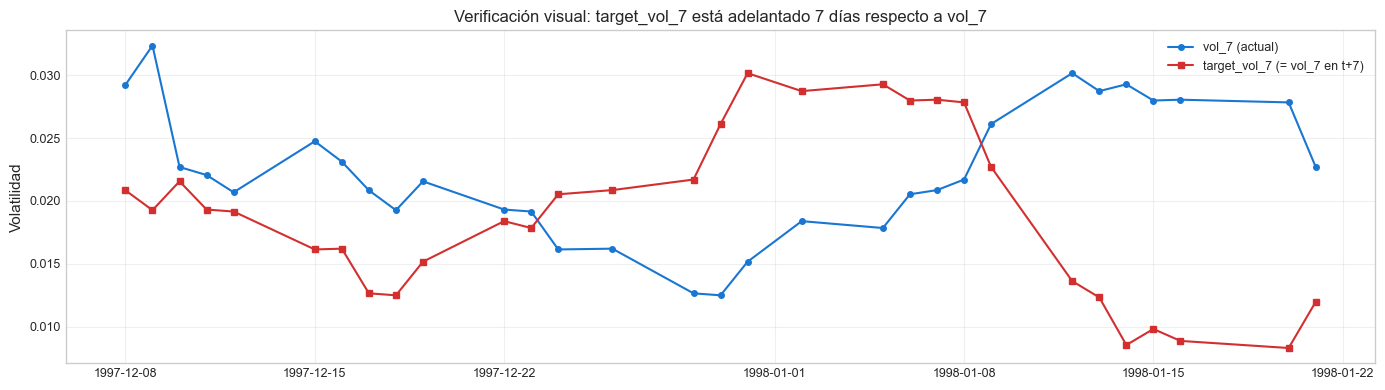

In [7]:
# Tomar una ventana corta para visualizar
sample = df[["date", "vol_7", "target_vol_7"]].dropna().iloc[2000:2030].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["date"], sample["vol_7"], "o-", label="vol_7 (actual)", color="#1976D2", markersize=4)
ax.plot(sample["date"], sample["target_vol_7"], "s-", label="target_vol_7 (= vol_7 en t+7)",
        color="#D32F2F", markersize=4)
ax.set_title("Verificación visual: target_vol_7 está adelantado 7 días respecto a vol_7")
ax.set_ylabel("Volatilidad")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** El gráfico muestra que `target_vol_7[t]` es exactamente igual a `vol_7[t+7]`: la línea roja está adelantada 7 posiciones respecto a la azul. Esta es la confirmación visual de que el shift está bien implementado y de que **el modelo, al predecir target_vol_7[t], realmente predice información futura** (no contemporánea ni pasada).


## 7. Construcción del dataset modelable y split temporal

In [8]:
# Filas válidas: las que tienen TODAS las features y al menos target_vol_7 y target_class
df_model = df.dropna(subset=feature_cols + ["target_vol_7", "target_class"]).copy()
df_model = df_model.sort_values("date").reset_index(drop=True)
print(f"Dataset modelable: {df_model.shape}")

# Split temporal 70/15/15
train, val, test = temporal_split(df_model)
print(split_summary(train, val, test))

Dataset modelable: (6965, 75)
Train:  4875 obs | 1990-03-13 → 2009-07-15
Val  :  1045 obs | 2009-07-16 → 2013-09-10
Test :  1045 obs | 2013-09-11 → 2017-11-01


---

> **📊 Interpretación:** El split temporal cubre tres regímenes históricos distintos: train (1990–2009) incluye el rally dot-com, su colapso y la crisis financiera; validation (2009–2013) cubre la recuperación post-crisis; test (2013–2017) es el período más reciente y cuasi-estable. **Este orden NO se altera con shuffle**, lo cual garantiza que el modelo siempre aprende sobre el pasado para predecir el futuro — es decir, simula condiciones realistas de despliegue en producción.


## 8. Visualizar el split

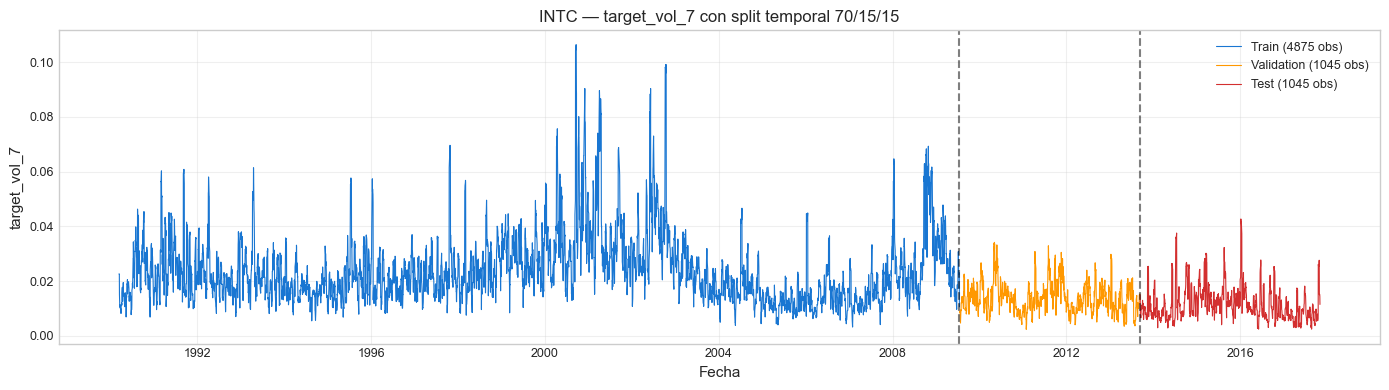

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["date"], train["target_vol_7"], color="#1976D2",
        linewidth=0.8, label=f"Train ({len(train)} obs)")
ax.plot(val["date"], val["target_vol_7"], color="#FF9800",
        linewidth=0.8, label=f"Validation ({len(val)} obs)")
ax.plot(test["date"], test["target_vol_7"], color="#D32F2F",
        linewidth=0.8, label=f"Test ({len(test)} obs)")
ax.axvline(train["date"].max(), color="black", linestyle="--", alpha=0.5)
ax.axvline(val["date"].max(), color="black", linestyle="--", alpha=0.5)
ax.set_title("INTC — target_vol_7 con split temporal 70/15/15")
ax.set_ylabel("target_vol_7")
ax.set_xlabel("Fecha")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** El test (rojo) es el último 15% del dataset y NUNCA se usa durante entrenamiento ni selección de modelos. La validación (naranja) se usa para selección de modelos en notebooks posteriores. El train (azul) es el bloque de aprendizaje. El test cubre 2013–2017, un período relativamente estable que ofrece un escenario realista de evaluación: si los modelos no funcionan en este período, claramente no servirían en producción.


## 9. Persistir todos los artefactos

In [ ]:
# Persistir el dataset completo con features+targets
path_full = save_processed(df_model, "features")
print(f"✅ Dataset modelable: {path_full}")

# Persistir splits para regresión
for name, frame in [("train_reg", train), ("val_reg", val), ("test_reg", test)]:
    path = save_processed(frame, name)
    print(f"   {path}")

# Para clasificación usamos el mismo split (las features son las mismas)
for name, frame in [("train_clf", train), ("val_clf", val), ("test_clf", test)]:
    path = save_processed(frame, name)
    print(f"   {path}")

# Lista de feature_cols (para no recalcularla)
import json
from src.config import DATA_PROCESSED
with open(DATA_PROCESSED / "feature_columns.json", "w") as f:
    json.dump(feature_cols, f, indent=2)
print(f"\n✅ feature_columns.json guardado con {len(feature_cols)} columnas")

✅ Dataset modelable: C:\Users\Mateo\2026\UNINORTE 2026 -1\ML\INTC-VolForecast\data\processed\features.parquet
   C:\Users\Mateo\2026\UNINORTE 2026 -1\ML\INTC-VolForecast\data\processed\train_reg.parquet
   C:\Users\Mateo\2026\UNINORTE 2026 -1\ML\INTC-VolForecast\data\processed\val_reg.parquet
   C:\Users\Mateo\2026\UNINORTE 2026 -1\ML\INTC-VolForecast\data\processed\test_reg.parquet
   C:\Users\Mateo\2026\UNINORTE 2026 -1\ML\INTC-VolForecast\data\processed\train_clf.parquet
   C:\Users\Mateo\2026\UNINORTE 2026 -1\ML\INTC-VolForecast\data\processed\val_clf.parquet
   C:\Users\Mateo\2026\UNINORTE 2026 -1\ML\INTC-VolForecast\data\processed\test_clf.parquet

✅ feature_columns.json guardado con 59 columnas


: 

---

## 10. Resumen

| Artefacto | Ubicación | Filas |
|---|---|---|
| Dataset completo | `data/processed/features.parquet` | ~6,950 |
| Train regresión | `data/processed/train_reg.parquet` | ~4,865 |
| Validation regresión | `data/processed/val_reg.parquet` | ~1,043 |
| Test regresión | `data/processed/test_reg.parquet` | ~1,043 |
| Lista de features | `data/processed/feature_columns.json` | 59 nombres |

**Procede al notebook `03_benchmarks_temporales.ipynb`** para ajustar los benchmarks econométricos clásicos (Naive, Rolling, EWMA, ARIMA, GARCH) sobre estos datos.
